<a href="https://colab.research.google.com/github/io-uty/skt-bigdata-analysis/blob/main/11_ML_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 9. 로지스틱 회귀 (Logistic Regression)

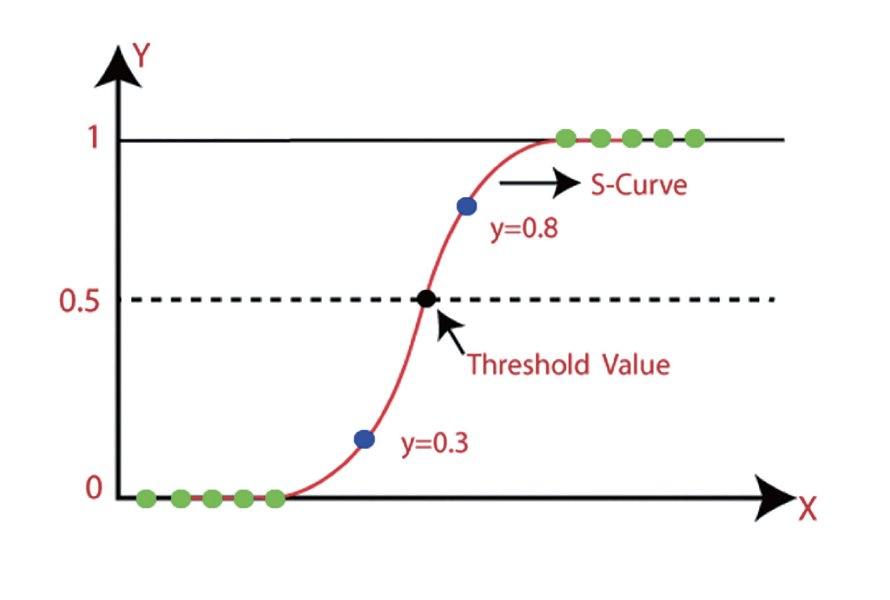

- 로지스틱 회귀(Logistic Regression)
  - 데이터가 어떤 범주에 속할 확률을 0에서 1 사이의 값으로 예측한다
  - 그 확률을 기준으로 데이터를 분류해주는 대표적인 지도 학습 기반 머신러닝 및 통계분류  알고리즘

- 가설 함수로 사용하는 곡선은
  - 시그모이드(Sigmoid) 또는 로지스틱 곡선이라 한다.
- 당뇨병 데이터 사용
  - diabetes.csv (피마 인디언 당뇨병 데이터셋)

https://raw.githubusercontent.com/plotly/datasets/refs/heads/master/diabetes.csv

In [1]:
import pandas as pd

diabetes = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/refs/heads/master/diabetes.csv')
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


- 이상치 처리

In [3]:
df = diabetes.copy(deep=True)
df = df.loc[:, ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', "BMI"]]

- 이상치의 개수 확인

In [4]:
def iszero(x):
    return x==0

df.apply(iszero).sum(axis=0)

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


In [7]:
import numpy as np

df = df.replace(0,np.nan)
df.isnull().sum(axis=0)

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


- 결측치 처리

In [8]:
df['Glucose'].fillna(df['Glucose'].mean(),
                     inplace=True)
df['BloodPressure'].fillna(df['BloodPressure'].mean(),
                     inplace=True)
df['SkinThickness'].fillna(df['SkinThickness'].mean(),
                     inplace=True)
df['Insulin'].fillna(df['Insulin'].mean(),
                     inplace=True)
df['BMI'].fillna(df['BMI'].mean(),
                     inplace=True)

df.isnull().sum(axis=0)


/tmp/ipykernel_1618/136505943.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Glucose'].fillna(df['Glucose'].mean(),
/tmp/ipykernel_1618/136505943.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0


In [9]:
from sklearn.model_selection import train_test_split

X = diabetes.iloc[:,:-1]
y = diabetes.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.2, stratify=y, random_state =42)
print('Train: ', X_train.shape, y_train.shape)
print('Test: ', y_train.shape, y_test.shape)

Train:  (614, 8) (614,)
Test:  (614,) (154,)


In [10]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


y_train = y_train.values
y_test = y_test.values

In [11]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [15]:
y_pred = lr.predict(X_test)
print(y_pred[:20])

[1 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 1 0 1 0]


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score
def print_scores(y_true, y_pred):
  print('accuracy_score: {0:.4f}'.format(accuracy_score(y_true, y_pred)))
  print('precision_score:{0:.4f}'.format(precision_score(y_true, y_pred)))
  print('recall_score: {0:.4f}'.format(recall_score(y_true, y_pred)))
print_scores(y_test, y_pred)

accuracy_score: 0.7143
precision_score:0.6087
recall_score: 0.5185


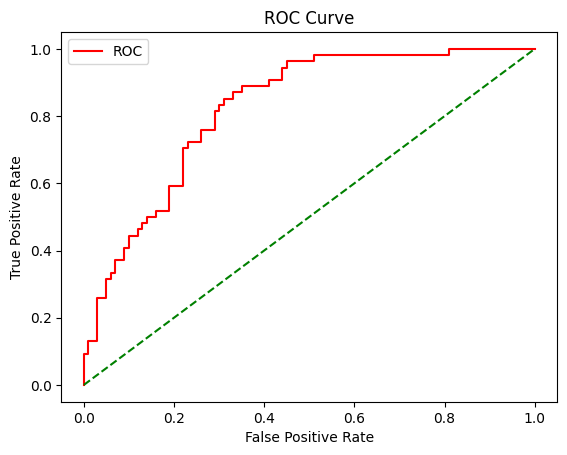

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

def plot_roc_curve(fper, tper):
    plt.plot(fper, tper, color='red', label='ROC')
    plt.plot([0, 1], [0, 1], color='green', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

y_proba = lr.predict_proba(X_test)
fper, tper, thresholds = roc_curve(y_test, y_proba[:, 1])
plot_roc_curve(fper, tper)